mini-project I
Machine Learning for Mental Health
Data loading and exploration with Pandas.

In [77]:
import pandas as pd
mhdata = pd.read_csv('survey.csv')
print(mhdata.head())
print(mhdata.info())      
 


             Timestamp  Age  Gender         Country state self_employed  \
0  2014-08-27 11:29:31   37  Female   United States    IL           NaN   
1  2014-08-27 11:29:37   44       M   United States    IN           NaN   
2  2014-08-27 11:29:44   32    Male          Canada   NaN           NaN   
3  2014-08-27 11:29:46   31    Male  United Kingdom   NaN           NaN   
4  2014-08-27 11:30:22   31    Male   United States    TX           NaN   

  family_history treatment work_interfere    no_employees  ...  \
0             No       Yes          Often            6-25  ...   
1             No        No         Rarely  More than 1000  ...   
2             No        No         Rarely            6-25  ...   
3            Yes       Yes          Often          26-100  ...   
4             No        No          Never         100-500  ...   

                leave mental_health_consequence phys_health_consequence  \
0       Somewhat easy                        No                      No   
1 

It's important to check whether there are duplicated rows 
getting all the unique number for every column
dropping the columns, like: ['State'],['care_options'], ['anonymity'], ['comments']

In [78]:
duplicate_count = mhdata.duplicated().sum()
print(duplicate_count)

mhdata_dc = mhdata.drop(columns=['state', 'self_employed', 'care_options', 'anonymity', 'comments', 'work_interfere'])
for col in mhdata_dc.columns:
    print(f"Unique values in '{col}':")
    print(mhdata_dc[col].unique())
    print("\n")

0
Unique values in 'Timestamp':
['2014-08-27 11:29:31' '2014-08-27 11:29:37' '2014-08-27 11:29:44' ...
 '2015-11-07 12:36:58' '2015-11-30 21:25:06' '2016-02-01 23:04:31']


Unique values in 'Age':
[         37          44          32          31          33          35
          39          42          23          29          36          27
          46          41          34          30          40          38
          50          24          18          28          26          22
          19          25          45          21         -29          43
          56          60          54         329          55 99999999999
          48          20          57          58          47          62
          51          65          49       -1726           5          53
          61           8          11          -1          72]


Unique values in 'Gender':
['Female' 'M' 'Male' 'male' 'female' 'm' 'Male-ish' 'maile' 'Trans-female'
 'Cis Female' 'F' 'something kinda male?' 'Cis Male' 

getting rid of outliners in ['Age'] and cleaning the rest of the table, introducing new feature = ['Year'] as per formatted date stamp

In [79]:
mhdata_dc_new = mhdata_dc[(mhdata_dc['Age'] >= 18) & (mhdata_dc['Age'] <= 72)]
mhdata_dc_new['Age'].unique()
mhdata_dc_new['Gender'] = mhdata_dc_new['Gender'].str.lower()

mhdata_dc_new['Gender'] = mhdata_dc_new['Gender'].str.lower()

mhdata_dc_new['Gender'] = mhdata_dc_new['Gender'].replace({
    'm': 'male', 'male': 'male', 'male-ish': 'male', 'cis male': 'male', 'mal': 'male', 
    'f': 'female', 'female': 'female', 'cis female': 'female', 'femake': 'female', 'woman': 'female', 
    'female (trans)': 'female', 'female (cis)': 'female', 'femail': 'female',
    'cis-female/femme': 'female', 'trans-female': 'female', 'cis man': 'male', 'make': 'male', 
    'msle': 'male', 'man': 'male', 'mail': 'male', 'malr': 'male', 'something kinda male?': 'male', 
    'maile': 'male', 'male (cis)': 'male', 'guy (-ish) ^_^': 'male', 'female ': 'female', 
    'male ': 'male', 'queer': 'other', 'non-binary': 'other', 'genderqueer': 'other', 'fluid': 'other', 
    'queer/she/they': 'other', 'enby': 'other', 'agender': 'other', 'androgyne': 'other', 'trans female': 'other', 
    'neuter': 'other', 'trans woman': 'other', 'nah': 'other', 'p': 'other', 'male leaning androgynous': 'other', 
    'ostensibly male, unsure what that really means': 'other'
})

print(mhdata_dc_new['Gender'].unique())


['female' 'male' 'other']


C:\Users\vaise\AppData\Local\Temp\ipykernel_44072\1410660442.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mhdata_dc_new['Gender'] = mhdata_dc_new['Gender'].str.lower()
C:\Users\vaise\AppData\Local\Temp\ipykernel_44072\1410660442.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mhdata_dc_new['Gender'] = mhdata_dc_new['Gender'].str.lower()
C:\Users\vaise\AppData\Local\Temp\ipykernel_44072\1410660442.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try

In [80]:
mhdata_dc_new['Timestamp'] = pd.to_datetime(mhdata_dc_new['Timestamp'])

# Extract the year from the 'Timestamp' column and create a new 'Year' column
mhdata_dc_new['Year'] = mhdata_dc_new['Timestamp'].dt.year

# Check the result by viewing the first few rows
mhdata_dc_new['Year'].unique()

C:\Users\vaise\AppData\Local\Temp\ipykernel_44072\4229671456.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mhdata_dc_new['Timestamp'] = pd.to_datetime(mhdata_dc_new['Timestamp'])
C:\Users\vaise\AppData\Local\Temp\ipykernel_44072\4229671456.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mhdata_dc_new['Year'] = mhdata_dc_new['Timestamp'].dt.year


array([2014, 2015, 2016], dtype=int32)

In [81]:
mhdata_dc_new.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1251 entries, 0 to 1258
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Timestamp                  1251 non-null   datetime64[ns]
 1   Age                        1251 non-null   int64         
 2   Gender                     1251 non-null   object        
 3   Country                    1251 non-null   object        
 4   family_history             1251 non-null   object        
 5   treatment                  1251 non-null   object        
 6   no_employees               1251 non-null   object        
 7   remote_work                1251 non-null   object        
 8   tech_company               1251 non-null   object        
 9   benefits                   1251 non-null   object        
 10  wellness_program           1251 non-null   object        
 11  seek_help                  1251 non-null   object        
 12  leave      

In [82]:
mhdata_dc_new.head()

,Timestamp,Age,Gender,Country,family_history,treatment,no_employees,remote_work,tech_company,benefits,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,Year
0,2014-08-27 11:29:31,37,female,United States,No,Yes,6-25,No,Yes,Yes,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,2014
1,2014-08-27 11:29:37,44,male,United States,No,No,More than 1000,No,No,Don't know,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,2014
2,2014-08-27 11:29:44,32,male,Canada,No,No,6-25,No,Yes,No,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,2014
3,2014-08-27 11:29:46,31,male,United Kingdom,Yes,Yes,26-100,No,Yes,No,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,2014
4,2014-08-27 11:30:22,31,male,United States,No,No,100-500,Yes,Yes,Yes,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,2014


Before calculating the percentage of people reporting mental health consequences for each combination of age group  per year, the dataset, mhdata_new, should be filtered first in the column ['tech_company'] , whilst yes/no replaced as 1/0.

in order to categorizing Age Groups: by means of age bins and labels, it is neccessary tocreate a new column Age Group that categorizes each person into one of the predefined age groups.
Grouping by Age Group and Year: the data by both Age Group and Year to get the distribution of mental health consequences over the years within each age group.
While mennmental_health_consequence are mapped as follows
'Yes' is mapped to 1, indicating a mental health issue.
'No' is mapped to 0, indicating no mental health issue.
'Maybe' is mapped to 1.
'Don't know' is mapped to 0

In [83]:
import numpy as np
tech_data = mhdata_dc_new.replace({'tech_company': {'Yes': 1, 'No': 0}})
tech_data = tech_data[tech_data['tech_company'] == 1]
mental_health_mapping = {
    'Yes': 1,
    'No': 0,
    'Maybe': 1, 
    'Don\'t know': 0 
}
tech_data['mental_health_consequence'] = tech_data['mental_health_consequence'].map(mental_health_mapping)

bins = [0, 25, 35, 45, 55, 100] 
labels = ['18-25', '26-35', '36-45', '46-55', '56+']
tech_data['Age Group'] = pd.cut(tech_data['Age'], bins=bins, labels=labels, right=False)



C:\Users\vaise\AppData\Local\Temp\ipykernel_44072\2868070214.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  tech_data = mhdata_dc_new.replace({'tech_company': {'Yes': 1, 'No': 0}})


In [84]:
age_year_group_analysis = tech_data.groupby(['Year', 'Age Group'])['mental_health_consequence'].value_counts(normalize=True).unstack(fill_value=0)
age_year_group_analysis = age_year_group_analysis * 100
age_year_group_analysis = age_year_group_analysis.rename(columns={0: 'No', 1: 'Yes'})

age_year_group_analysis



C:\Users\vaise\AppData\Local\Temp\ipykernel_44072\1709271370.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_year_group_analysis = tech_data.groupby(['Year', 'Age Group'])['mental_health_consequence'].value_counts(normalize=True).unstack(fill_value=0)


mental_health_consequence         No         Yes
Year Age Group                                  
2014 18-25                 49.152542   50.847458
     26-35                 41.929825   58.070175
     36-45                 39.565217   60.434783
     46-55                 44.736842   55.263158
     56+                   30.769231   69.230769
2015 18-25                 30.000000   70.000000
     26-35                 33.333333   66.666667
     36-45                 45.454545   54.545455
     46-55                 25.000000   75.000000
     56+                    0.000000  100.000000

the visiual is as follows:

C:\Users\vaise\AppData\Local\Temp\ipykernel_44072\1663055622.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Year', y='Yes', hue='Age Group', data=age_year_group_analysis.reset_index(), ci=None)


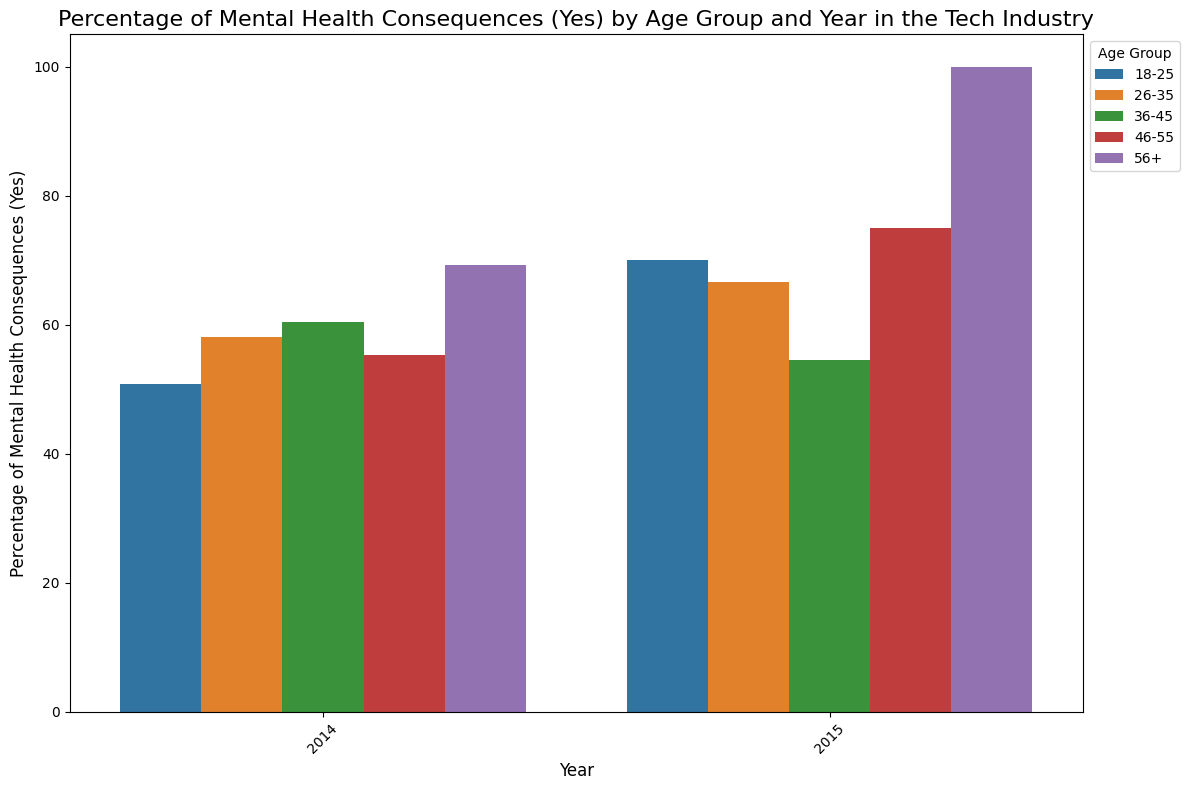

In [85]:
import matplotlib.pyplot as plt
import seaborn as sns
age_year_group_analysis = age_year_group_analysis.rename(columns={0: 'No', 1: 'Yes'})

plt.figure(figsize=(12, 8))
sns.barplot(x='Year', y='Yes', hue='Age Group', data=age_year_group_analysis.reset_index(), ci=None)

plt.title('Percentage of Mental Health Consequences (Yes) by Age Group and Year in the Tech Industry', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Percentage of Mental Health Consequences (Yes)', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Age Group', loc='upper left', bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()


In order to analyze how the frequency of mental health issues varies by gender and by year it is necessary to group tech_databy by gender and year and then calculate the percentage of people reporting mental health issues (Yes/No) for each gender and year.


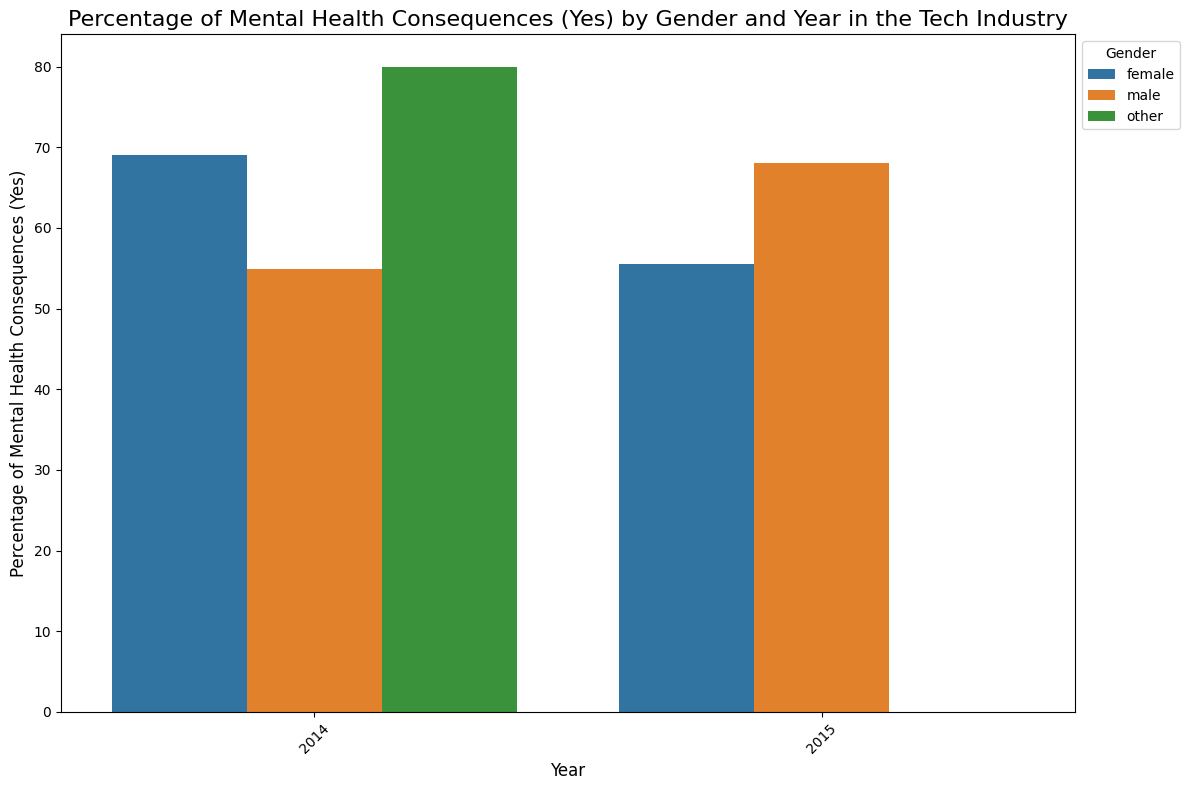

In [88]:
import matplotlib.pyplot as plt
import seaborn as sns

gender_year_group_analysis = tech_data.groupby(['Year', 'Gender'])['mental_health_consequence'].value_counts(normalize=True).unstack(fill_value=0)
gender_year_group_analysis = gender_year_group_analysis * 100
gender_year_group_analysis = gender_year_group_analysis.rename(columns={0: 'No', 1: 'Yes'})


plt.figure(figsize=(12, 8))
sns.barplot(x='Year', y='Yes', hue='Gender', data=gender_year_group_analysis.reset_index())
plt.title('Percentage of Mental Health Consequences (Yes) by Gender and Year in the Tech Industry', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Percentage of Mental Health Consequences (Yes)', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Gender', loc='upper left', bbox_to_anchor=(1, 1))

# Show the plot
plt.tight_layout()
plt.show()


Grouping the data by country and year and calculating the percentage of people reporting mental health consequences (Yes and No) and then sorting the countries by their percentage of reported mental health issues for each year, identifying the countries with the highest and lowest percentages.

In [91]:


country_year_group_analysis = tech_data.groupby(['Year', 'Country'])['mental_health_consequence'].value_counts(normalize=True).unstack(fill_value=0)
country_year_group_analysis = country_year_group_analysis * 100
country_year_group_analysis = country_year_group_analysis.rename(columns={0: 'No', 1: 'Yes'})

highest_lowest_countries = country_year_group_analysis.groupby('Year')['Yes'].agg(['idxmax', 'idxmin'])
print(highest_lowest_countries)



                 idxmax           idxmin
Year                                    
2014    (2014, Belgium)  (2014, Austria)
2015  (2015, Australia)   (2015, Brazil)
